## SNRClassifier 1

Define the needed functions. Load the data and scale the features even though in this case values of magnitude are quite similar

In [1]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_curve, accuracy_score, precision_score
import corner
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from astroML.utils import completeness_contamination
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, mean_squared_error

C:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


One can maximize different things during cross validation. I tried optimizing the contamination (low as possible) and the rms. Similar results are obtained

In [18]:
def geterror(y_true,y_pred):
    completeness, contamination = completeness_contamination(y_pred, y_true)
    return contamination
scorer = make_scorer(geterror, greater_is_better=False)
scorer = 'neg_mean_squared_error'

def CrossVal(clf,param_grid):
    grid = GridSearchCV(clf, param_grid,scoring= scorer, cv=5, return_train_score = True)
    grid.fit(Xtrain, ytrain)
    
    scores = (np.column_stack((-grid.cv_results_['mean_test_score'],-grid.cv_results_['mean_train_score'])))
    fig, ax = plt.subplots()
    ax.plot(list(param_grid.values())[0],scores,label=['test','train'])
    ax.set_ylabel('Error (score)')
    ax.set_xlabel(list(param_grid.keys())[0])
    ax.set_title(f'Grid Search Results for {clf.__class__.__name__}')
    plt.legend()
    print(f'The best is {grid.best_params_}')
    return grid.best_estimator_

def PlotModel(setylim=True):
    # Plot ROC curves and completeness/efficiency
    fig = plt.figure(figsize=(15, 5))
    fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)

    # ax1 will show roc curves
    ax1 = plt.subplot(131)
    
    # ax2 will show completeness/efficiency
    # ax2 = plt.subplot(132)
    
    # ax3 will show precision/recall
    # ax3 = plt.subplot(133)

    # iterate through and show results
    for clf, y_prob, y_pred, name in zip(classifiers, probs, preds, names):
        fpr, tpr, thresh = roc_curve(ytest, y_prob)
        # precision, recall, thresh2 = precision_recall_curve(ytest, y_prob)
    
        # add (0, 0) as first point
        fpr = np.concatenate([[0], fpr])
        tpr = np.concatenate([[0], tpr])
        # Here we add (1,0) 
        # precision = np.concatenate([[0], precision])
        # recall = np.concatenate([[1], recall])
        # thresh2 = np.concatenate([[0], thresh2])
    
        ax1.plot(fpr, tpr, label=name)
    
        #See note above about astroML vs. sklearn
        #Note that the range of threshhold values here is 0% to 100% (0.0 to 1.0)
        # thresholds = np.linspace(0, 1, 1001)[:-1]
        # comp = np.zeros_like(thresholds)
        # cont = np.zeros_like(thresholds)
        # for i, t in enumerate(thresholds):
        #     y_pred = (y_prob >= t)
        #     comp[i], cont[i] = completeness_contamination(y_pred, y_test)
        # ax2.plot(1 - cont, comp, label=labels[name])
        
        #ax3.plot(precision, recall, label=labels[name])
    
    ax1.set_xlim(0, 0.2)
    if setylim:
        ax1.set_ylim(0.6, 1.02)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax1.set_xlabel('false positive rate')
    ax1.set_ylabel('true positive rate')
    ax1.legend(loc=4)
    
    # ax2.set_xlabel('efficiency')
    # ax2.set_ylabel('completeness')
    # ax2.set_xlim(0, 1.0)
    # ax2.set_ylim(0.2, 1.02)
    
    #ax3.set_xlabel('precision')
    #ax3.set_ylabel('recall')
    #ax3.set_xlim(0, 1.0)
    #ax3.set_ylim(0.2, 1.02)
    
    plt.show()
    
def compute_models(*args):
    names = []
    probs = []
    classifiers = []
    preds = []
    completenesses = []
    contaminations = []
    sorted_features = []
    accuracies = []
    precisions = []
    for classifier, kwargs, cvargs in args:
        print(classifier.__name__)
        clf = classifier(**kwargs)
        if not cvargs:
            clf.fit(Xtrain, ytrain)
        else:
            clf = CrossVal(clf, cvargs)
        #Note that we are outputing the probabilities [of class 1], not the classes
        y_probs = clf.predict_proba(Xtest)[:, 1]
        y_pred = clf.predict(Xtest)
        completeness, contamination = completeness_contamination(y_pred, ytest)
    
        names.append(classifier.__name__)
        probs.append(y_probs)
        preds.append(y_pred)
        classifiers.append(clf)
        completenesses.append(completeness)
        contaminations.append(contamination)
        accuracies.append(accuracy_score(ytest,y_pred))
        precisions.append(precision_score(ytest,y_pred))
        sorted_features.append(get_sorted_feature_importance(clf,Xtest.columns,5))
        print("completeness", completeness)
        print("contamination", contamination)
        print("accuracy:", accuracy_score(ytest, y_pred))
        print("precision:", precision_score(ytest, y_pred))

        

    return classifiers, probs, preds, names, completenesses, contaminations, accuracies, precisions

def get_sorted_feature_importance(model, feature_names, top_n=None):
    # Tree-based models
    importance = True
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        sorted_features = [(feature_names[i], importances[i]) for i in indices]
        label = "Feature importances (tree-based):"

    # Linear models
    elif hasattr(model, 'coef_'):
        coefs = model.coef_
        indices = np.argsort(np.abs(coefs))[::-1]
        sorted_features = [(feature_names[i], coefs[i]) for i in indices]
        label = "Feature importances (linear model, by |coef|):"

    else:
        label = "Model does not have feature_importances_ or coef_ attribute."
        importance = False

    # Select top N features if specified
    if importance:
        if top_n is not None:
            sorted_features = sorted_features[:top_n]
    
        print(label)
        for name, importance in sorted_features:
            print(f"{name}: {importance:.4f}")
    else:
       sorted_features = [] 

    return sorted_features

In [5]:
with h5py.File(r"sample_2e7_design_precessing_higherordermodes_3detectors.h5", 'r') as f:
    # Read all datasets into a dictionary
    data = {key: f[key][:] for key in f.keys()}

df_origin = pd.DataFrame(data)

Scale the data and start using all the features

In [6]:
np.random.seed(42)
df = df_origin.iloc[np.random.choice(len(df_origin), size=50000, replace=False)].copy()
scaler = StandardScaler()

features = [col for col in df.columns if col not in ['det','snr']]
df[features] = scaler.fit_transform(df[features])

# features to use
features = [col for col in df.columns if col not in ['det','snr']]
X = df[features]
y = df['det']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,test_size=0.3)

Plot histogram of features divided by detecteability and also corner plots to explore quickly the data

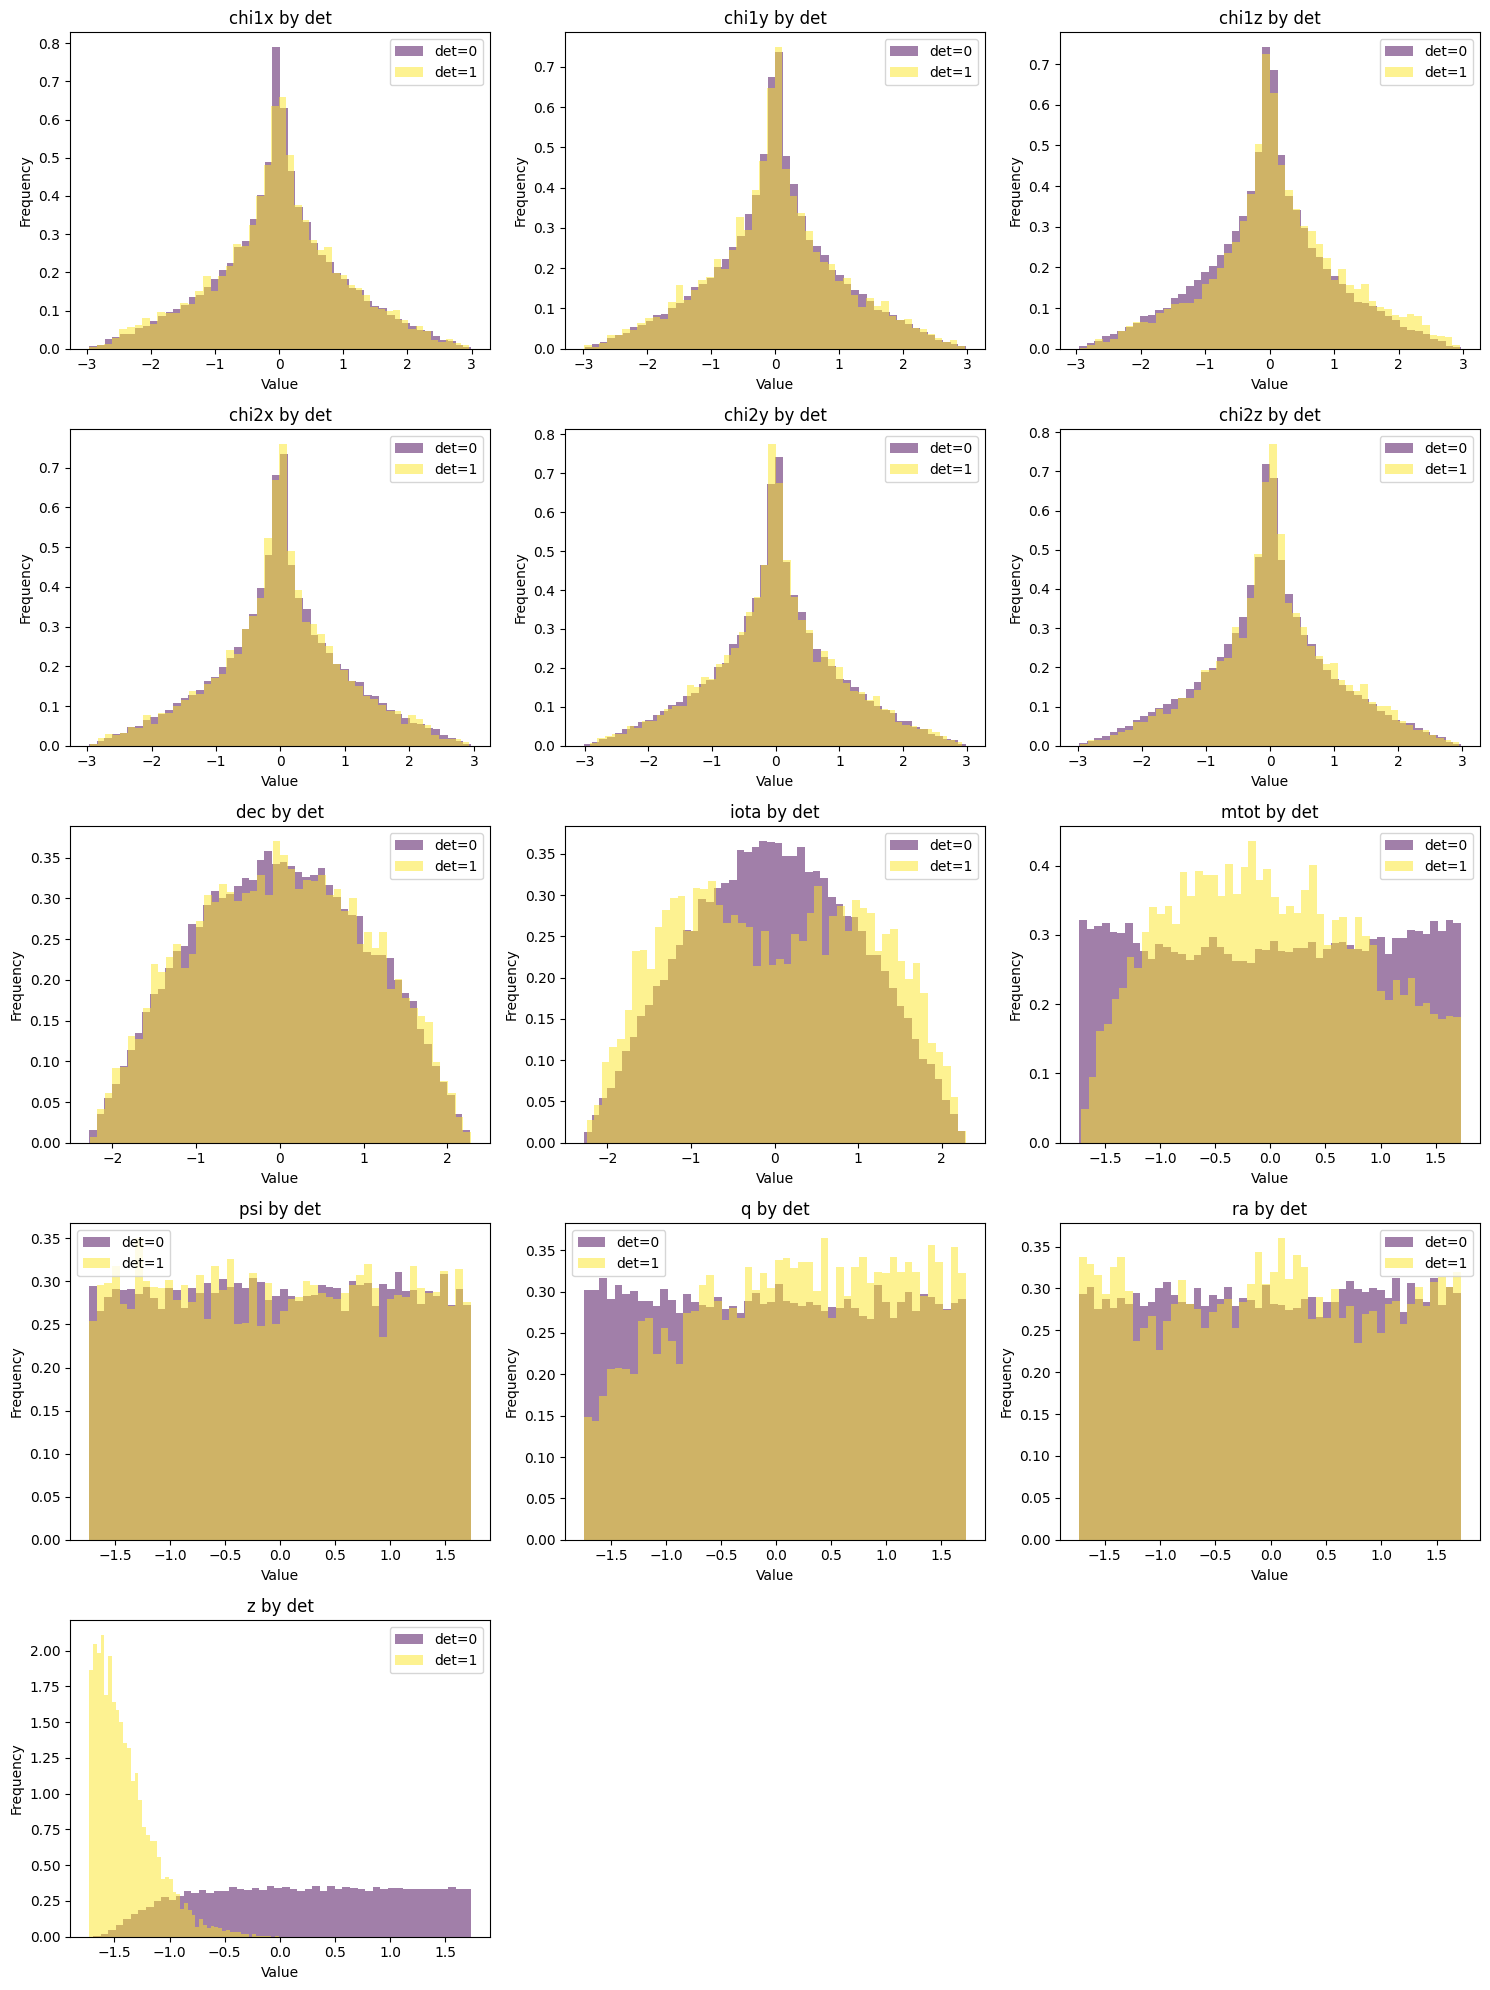

In [8]:
det_values = np.unique(df['det'])

n_features = len(features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

colors = plt.cm.viridis(np.linspace(0, 1, len(det_values)))

for i, feature in enumerate(features):
    for j, det_val in enumerate(det_values):
        subset = df[df['det'] == det_val][feature]
        axes[i].hist(subset, bins=50, alpha=0.5, color=colors[j], label=f'det={det_val}',density=True)
    axes[i].set_title(f"{feature} by det")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Probably the z mtot iota and q are the most significant features to use. Will check

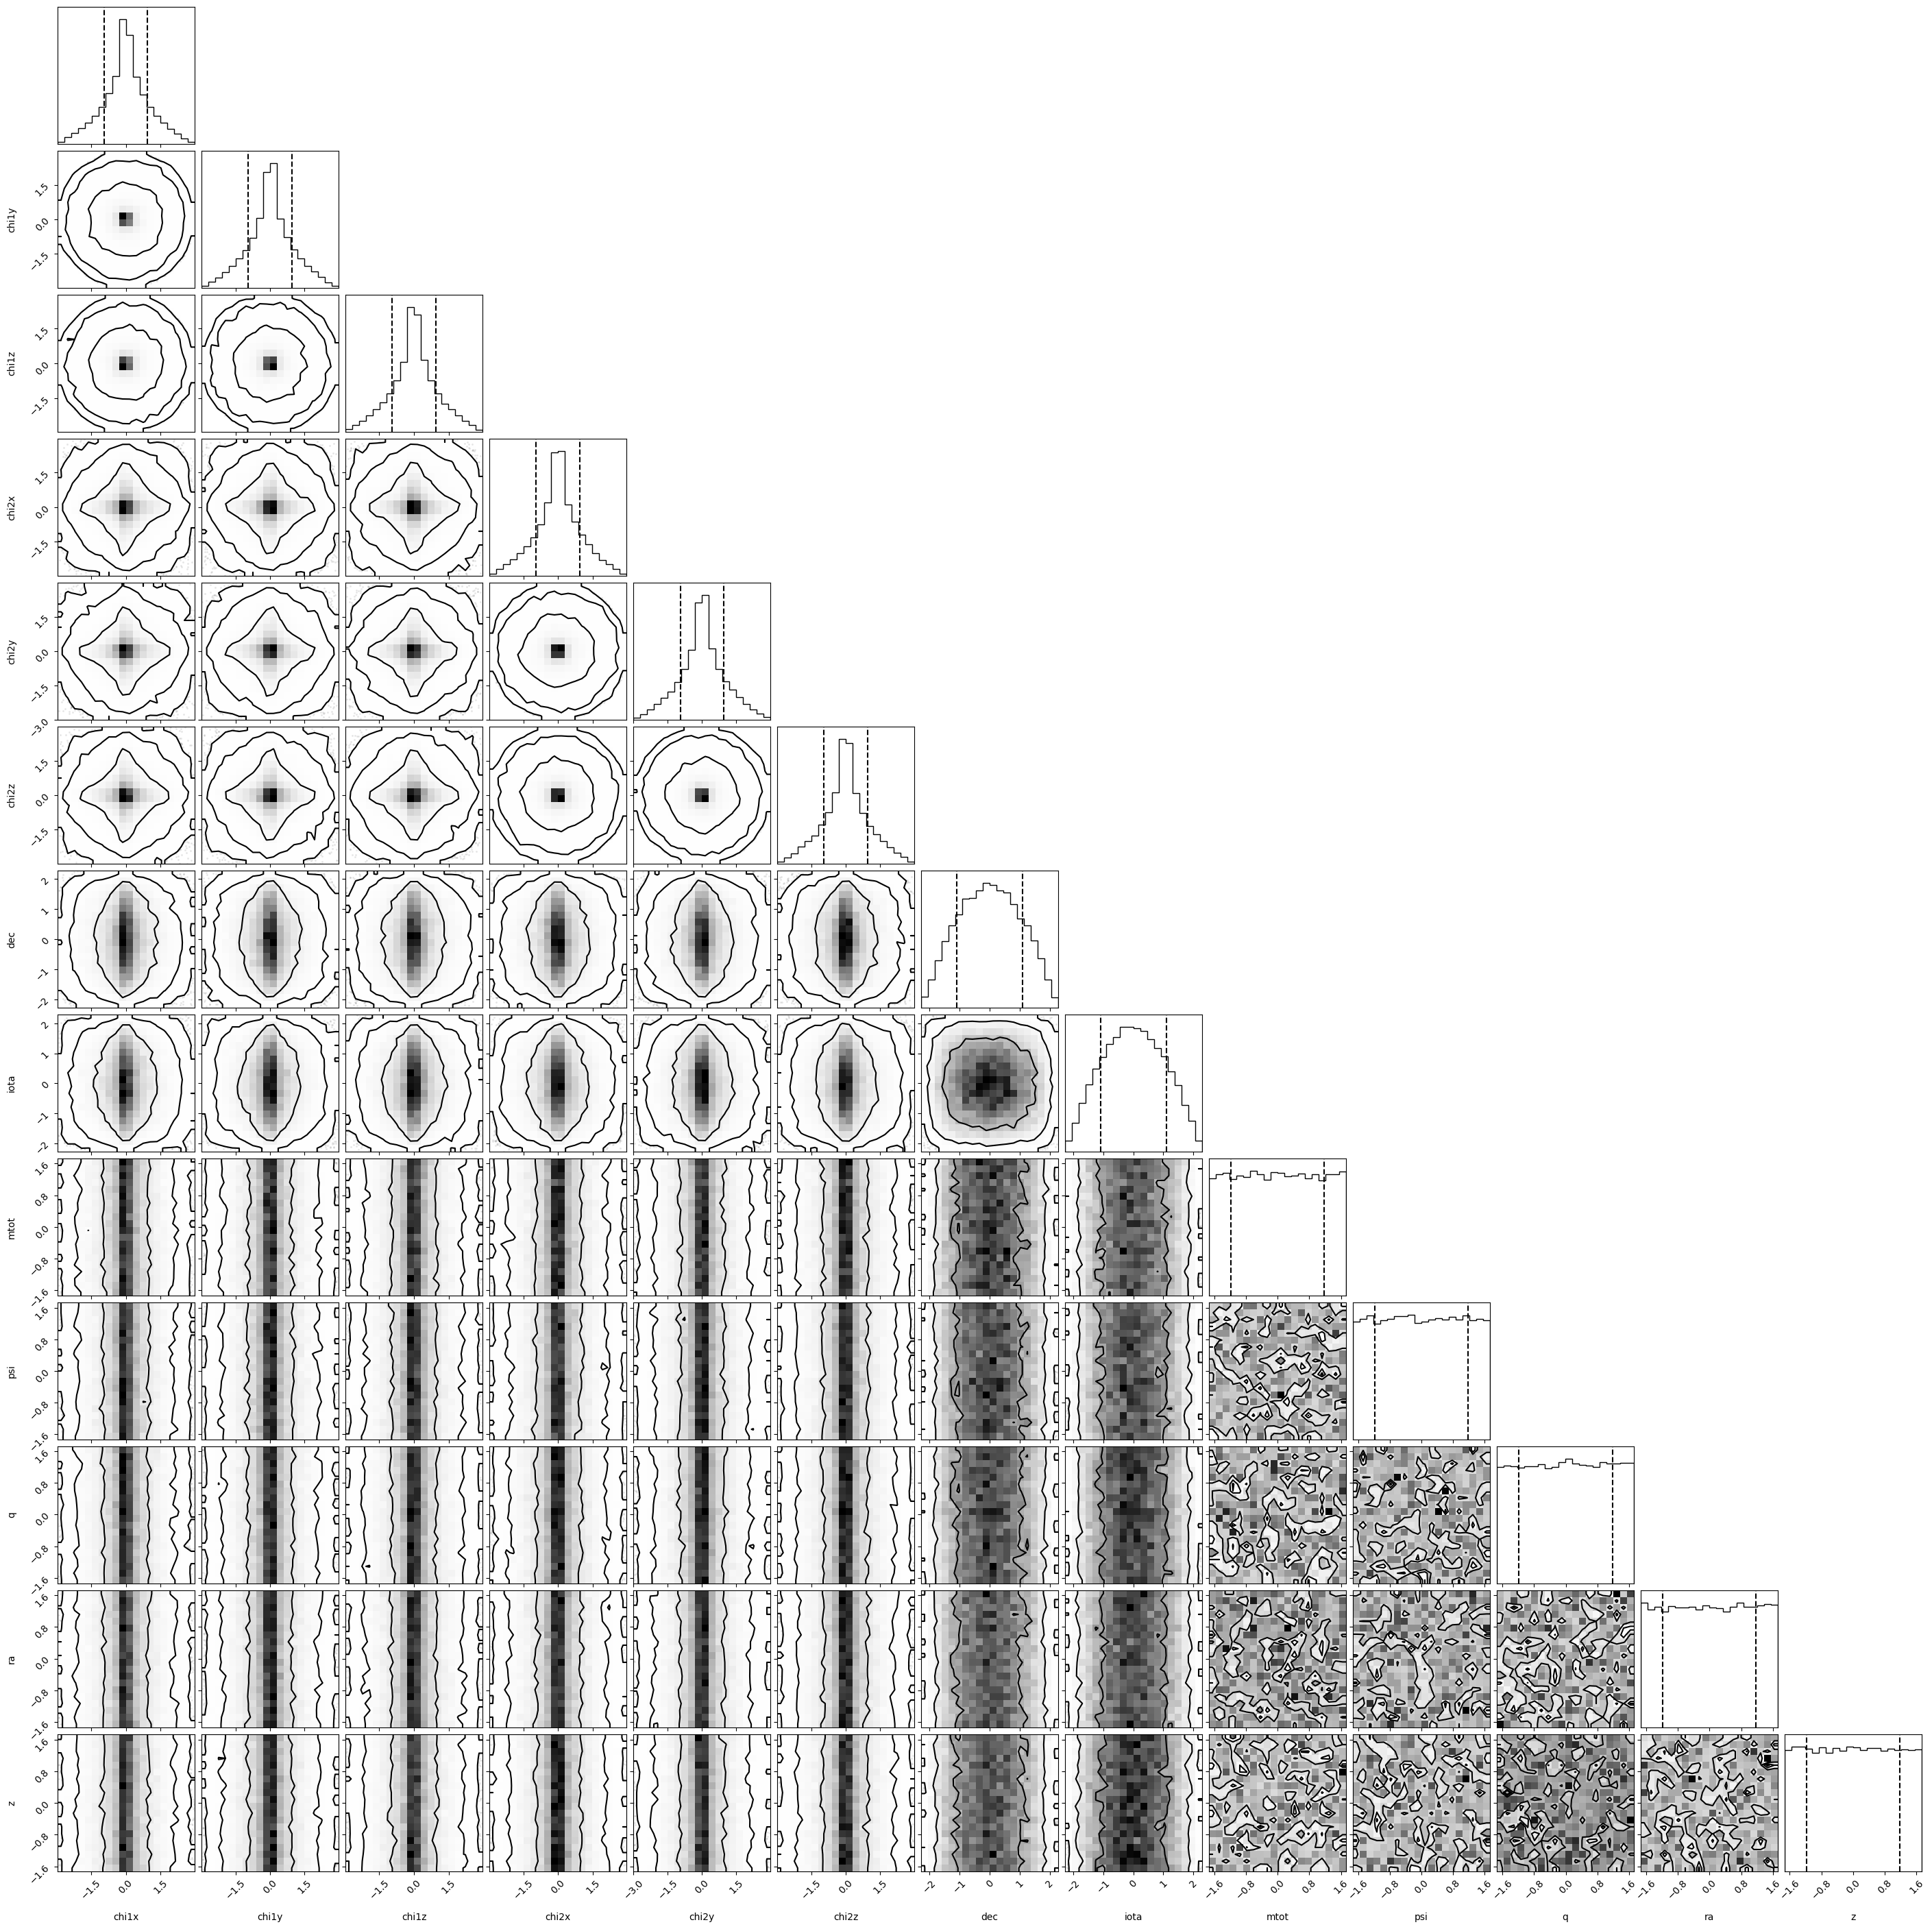

In [9]:
corner.corner(df[features], labels=features, quantiles=(0.16, 0.84),levels=(0.68,0.95,0.997));


No apparent correlations.

Explore random forest and cross validate the depth

RandomForestClassifier
The best is {'max_depth': 19}
Feature importances (tree-based):
z: 0.6819
mtot: 0.0634
iota: 0.0513
q: 0.0339
chi1z: 0.0278
completeness 0.8488909426987061
contamination 0.10911736178467507
accuracy: 0.9632
precision: 0.8908826382153249


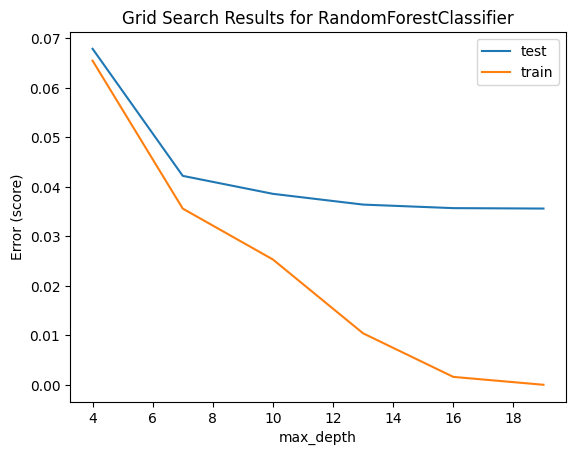

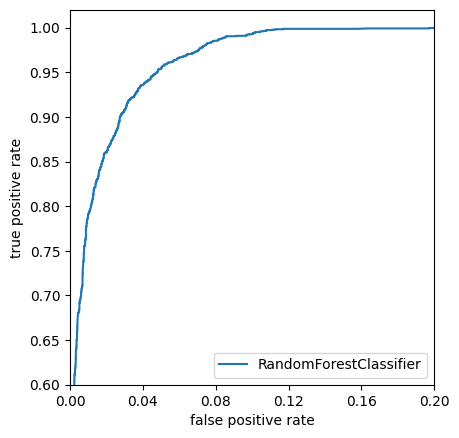

In [10]:
classifiers, probs, preds, names, completenesses, contaminations, accuracies, precisions = compute_models(
                              (RandomForestClassifier, dict(criterion='entropy'),{'max_depth': list(np.arange(4,20,3))}),
                              )
PlotModel(True)

Seems that the most important features are the one previously seen by looking the histograms. will use these to speed up the algo. Explore also GradientBoostingClassifier and SVC (for the regularization it takes a lot of time to do 1 analysis only...)

In [14]:
np.random.seed(42)
df = df_origin.iloc[np.random.choice(len(df_origin), size=100000, replace=False)].copy()
scaler = StandardScaler()

features = [col for col in df.columns if col not in ['det','snr']]
df[features] = scaler.fit_transform(df[features])

# features to use
features = ['z','mtot','iota','q']
X = df[features]
y = df['det']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,test_size=0.3)

RandomForestClassifier
Feature importances (tree-based):
z: 0.7393
mtot: 0.1011
iota: 0.0958
q: 0.0638
completeness 0.8542349087505849
contamination 0.11768970517158048
accuracy: 0.963
precision: 0.8823102948284195
GradientBoostingClassifier
The best is {'max_depth': 7}
Feature importances (tree-based):
z: 0.7708
mtot: 0.1084
iota: 0.0759
q: 0.0449
completeness 0.8598502573701451
contamination 0.11828214971209212
accuracy: 0.9636
precision: 0.8817178502879078
SVC
completeness 0.8647636874122602
contamination 0.11705685618729098
accuracy: 0.9644
precision: 0.882943143812709


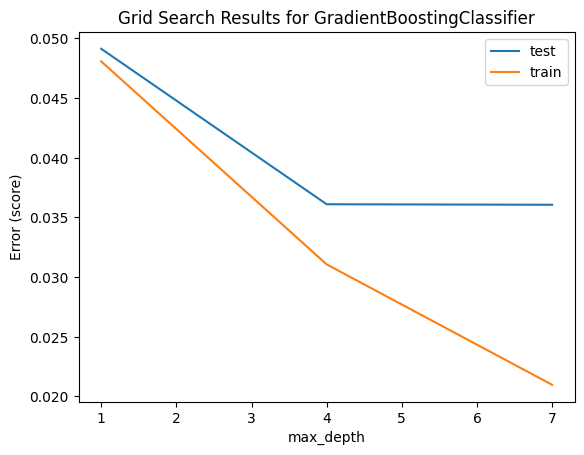

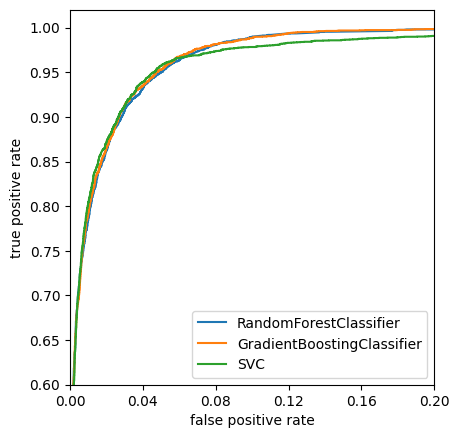

In [17]:
classifiers, probs, preds, names, completenesses, contaminations, accuracies, precisions = compute_models(
                              (RandomForestClassifier, {'criterion':'entropy','max_depth':19},{}),
                              (GradientBoostingClassifier, {}, {'max_depth': list(np.arange(1,10,3))}),
                              (SVC, {'probability':True},{})#,{'C':[0.01,0.1,1,10]})
                              )
PlotModel(True)

All the three algos provide similar results